# 014 — Site case-study collapse fragilities in AvgSA

Re-express the IDA-based **collapse fragilities** of the 60 per-site three-storey
EC8-gen2 case-study CBFs (designed in `011`) from their native **SA(T1)**
(5%-damped spectral acceleration at the fundamental period) into the two
intensity measures used by the site hazard / disaggregation / MSA work:
**AvgSA_03** (geometric-mean SA over 0–3 s) and **AvgSA_06** (0–6 s). This lets
fragility and hazard be combined in a common IM.

This is the site-specific counterpart of `013`, which does the same for the 9
scenario-A reference CBFs. The conversion machinery is identical; the differences are
that each site's IDA folder is keyed by its `site_idx`
(`D:/07_wp1_casestudy_sites/site_{ii}/{ns}s/mdof/ida_femap695`) rather than by the
structure tag, and that the fragilities written here are expressed as a **fraction of
g** (the raw IDA IMLs are in mm/s²), whereas `013` keeps mm/s².

Collapse is a linearly-scalable event, so for each record
`AvgSA_collapse = (SA(T1)_collapse / SA(T1)_record) · AvgSA_record`, and a
method-of-moments lognormal is refit in the new IM — exactly
`standes.analysis.ida.convert_ida_collapse_imls` + `fragility_from_ida`.

**Inputs**
- Fragility IDA outputs from `011`: `<wp1_casestudy_sites>/site_{ii}/{ns}s/mdof/ida_femap695/`
  (`ida_results.pickle`, `record_logs.json`, `record_*/ida_log_record_*.json`).
- Design base-shear coefficient `Vb_coeff` from the `011` site dataset
  (`site_specific_dataset`) — read, **not** recomputed.

**Outputs** — three JSON fragilities per structure in
`data_processed/09_structure_fragility_curves/wp1_casestudy_sites/site_{ii}/`,
named `{tag}_{ida_tag}_collapsefragility_{im}.json` for `im ∈ {SA, AvgSA_03, AvgSA_06}`
(`tag = 3s_cbf_dc2_site{ii}`), each with a `<file>.manifest.json` provenance sidecar
so only structures whose inputs changed are re-converted. Medians and empirical
curves are in **g**; dispersions are the dimensionless lognormal β.

> **Run order.** Requires `011`'s FEMA-P695 IDA to have been run (the
> `ida_femap695/` folders must exist). Sites without IDA output are skipped with a
> message. The IDA results live on `D:` — run this on the machine that has them.

## 0. Setup & parameters

In [ ]:
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.stats import lognorm

from phd_project.config import config
from phd_project.scripts.cache_utils import fingerprint, write_manifest
from standes.analysis.ida import (
    collect_ida_results, collect_record_logs, get_collapse_iml,
    convert_ida_collapse_imls, fragility_from_ida,
)
from standes.intensitymeasures import SpectralAcceleration, avgsa_03, avgsa_06
from standes.groundmotion import load_ground_motion_from_json

cfg = config.load_config()

In [ ]:
# ----------------------------------------------------------------------------
# PARAMETERS
# ----------------------------------------------------------------------------
# Root of the per-site analysis folders written by nb 011. Per site the FEMA P695
# IDA lives at IDA_ROOT/site_{ii}/mdof/ida_femap695/.
IDA_ROOT = Path(cfg["analysis_data"]["wp1_casestudy_sites"])

# Site dataset (nb 011) that carries the base-shear coefficient Vb_coeff and site_idx.
SITE_DATASET = Path(cfg["proc_data"]["site_specific_dataset"])
N_STOREYS = [3]

# Where the converted fragilities are written.
OUT_DIR = Path(cfg["proc_data"]["wp1_sites_fragility_curves"])
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Force a full re-conversion even when the provenance manifest still matches.
FORCE_RECOMPUTE = True

# IML units of the IDA [mm/s^2]. Every fragility written here is rescaled by
# 1/GRAVITY so all medians and empirical curves are a fraction of g.
GRAVITY = 9810.0

# Target intensity measures for the conversion (SA(T1) is handled separately as the
# native IM: its fragility is refit from the IDA's own collapse IMLs).
AVGSA_IMS = {"AvgSA_03": avgsa_03(), "AvgSA_06": avgsa_06()}
IM_ORDER = ["SA", "AvgSA_03", "AvgSA_06"]  # panel order

IDA_TAG = "ida_femap695"

print(f"IDA_ROOT     = {IDA_ROOT}")
print(f"SITE_DATASET = {SITE_DATASET}")
print(f"OUT_DIR      = {OUT_DIR}")

## 1. Site structures & design base-shear coefficient

Take the 60 per-site three-storey case-study structures from the `011` site dataset and
read their design base-shear coefficient `Vb_coeff = Vb/Wt` straight from it (no
recomputation). Each structure's IDA folder is `IDA_ROOT/site_{site_idx}/mdof/ida_femap695`
— note the folder is keyed by `site_idx`, not by the structure tag.

In [3]:
designs = pd.read_pickle(SITE_DATASET)
designs = designs[designs["n_storeys"].isin(N_STOREYS)].copy()
designs = designs.sort_values("Vb_coeff").reset_index(drop=True)

TAGS = designs["name"].tolist()
VB_COEFF = dict(zip(designs["name"], designs["Vb_coeff"]))
SITE_IDX = dict(zip(designs["name"], designs["site_idx"].astype(int)))
NS = dict(zip(designs["name"], designs["n_storeys"].astype(int)))

def ida_folder(tag: str, ida_tag: str) -> Path:
    return IDA_ROOT / f"site_{SITE_IDX[tag]}" / f"{NS[tag]}s/mdof/{ida_tag}"

designs["ida_exists"] = [ida_folder(t, IDA_TAG).is_dir() for t in TAGS]
print(f"{len(TAGS)} site structures; {int(designs['ida_exists'].sum())} have IDA output on disk")
designs[["name", "site_idx", "n_storeys", "Vb", "Wt", "Vb_coeff", "ida_exists"]]

60 site structures; 60 have IDA output on disk


,name,site_idx,n_storeys,Vb,Wt,Vb_coeff,ida_exists
0,3s_cbf_dc2_site29,29,3,7.990584e+04,3061800.0,0.026098,True
1,3s_cbf_dc2_site4,4,3,7.990584e+04,3061800.0,0.026098,True
2,3s_cbf_dc2_site8,8,3,7.990584e+04,3061800.0,0.026098,True
3,3s_cbf_dc2_site19,19,3,7.990584e+04,3061800.0,0.026098,True
4,3s_cbf_dc2_site27,27,3,8.046056e+04,3061800.0,0.026279,True
5,3s_cbf_dc2_site26,26,3,8.047403e+04,3061800.0,0.026283,True
6,3s_cbf_dc2_site0,0,3,8.738487e+04,3061800.0,0.028540,True
7,3s_cbf_dc2_site25,25,3,8.974180e+04,3061800.0,0.029310,True
8,3s_cbf_dc2_site3,3,3,9.714591e+04,3061800.0,0.031728,True
9,3s_cbf_dc2_site5,5,3,1.060324e+05,3061800.0,0.034631,True


## 2. Provenance-aware JSON cache

`json_load_or_compute` mirrors `cache_utils.load_or_compute` but writes JSON: it
reuses the cached fragility only when its `<file>.manifest.json` sidecar still
matches the current input fingerprint, and otherwise re-converts and rewrites both.
This is the "only repeat conversions for fragility curves that have changed" logic —
a changed `ida_results.pickle` (i.e. a re-run IDA) invalidates the cache.

In [4]:
def _np_default(o):
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    raise TypeError(f"not JSON serialisable: {type(o)}")


def _changed_inputs(cached: dict, current: dict) -> list[str]:
    """Names of inputs whose content hash differs between two fingerprints."""
    return [name for name in sorted(set(cached) | set(current))
            if cached.get(name, {}).get("hash") != current.get(name, {}).get("hash")]


def json_load_or_compute(artifact_fp: Path, fp_dict: dict, compute_fn,
                         force: bool = False, input_paths: dict | None = None):
    # Return (fragility_dict, status) where status is 'cached' or 'computed'.
    # When a cached artifact is present but stale, print the file path of each
    # input that changed (from input_paths) before recomputing.
    artifact_fp = Path(artifact_fp)
    manifest_fp = artifact_fp.with_name(artifact_fp.name + ".manifest.json")
    input_paths = input_paths or {}

    if not force and artifact_fp.is_file() and manifest_fp.is_file():
        cached = json.load(open(manifest_fp)).get("inputs", {})
        changed = _changed_inputs(cached, fp_dict)
        if not changed:
            with open(artifact_fp) as f:
                return json.load(f), "cached"
        for name in changed:
            where = input_paths.get(name)
            where = str(where) if where is not None else f"input '{name}' (no file path)"
            print(f"[stale] {artifact_fp.name}: recomputing -- changed input: {where}")

    result = compute_fn()
    artifact_fp.parent.mkdir(parents=True, exist_ok=True)
    with open(artifact_fp, "w") as f:
        json.dump(result, f, indent=2, default=_np_default)
    write_manifest(artifact_fp, fp_dict)
    return result, "computed" 

## 3. Convert each structure

For each structure: read its IDA results and per-record logs, recover the design
period `T1` (and hence the native `SpectralAcceleration(T1)`) from the IDA intensity
measure, load the ground-motion records, and convert the collapse IMLs into each
AvgSA.

All three curves — the native SA(T1) as well as the two AvgSA — are refit from the
per-record collapse IMLs with `fragility_from_ida`, so they all come out
in the **same units**. The IDA IMLs are in mm/s², so `g_factor = 1/GRAVITY` rescales
them to a fraction of g: the median and the empirical curve are in g, the
dimensionless dispersion is unchanged. The SA fit reproduces the IDA's own
`collapse_fragility.json` exactly (`get_collapse_iml` returns the same
`spline[-1, 1]` that the collapse fragility fits), only rescaled.

`convert_ida_collapse_imls` is left at its default `gravity_factor=1`: that factor
scales both intensity measures inside `convert_im` and cancels out of the ratio, so
it cannot change the output units — only `g_factor` can.

In [ ]:
def parse_T1(logs: dict) -> float:
    im_str = next(iter(logs.values()))["intensity_measure"]
    return float(re.search(r"period=([0-9.eE+-]+)", im_str).group(1))


def process_structure(tag: str, ida_tag, force: bool = FORCE_RECOMPUTE):
    fol = ida_folder(tag, ida_tag)
    if not fol.is_dir():
        print(f"[skip] {tag}: no IDA output at {fol}")
        return None

    ida_results = collect_ida_results(fol)
    logs = collect_record_logs(fol)
    original_im = SpectralAcceleration(parse_T1(logs))
    gm_records = {n: load_ground_motion_from_json(Path(logs[n]["record_path"]))
                  for n in ida_results}

    out = {}

    # --- structure out dir
    out_dir = OUT_DIR / f"site_{SITE_IDX[tag]}"
    out_dir.mkdir(parents=True, exist_ok=True)

    ida_results_fp = fol / "ida_results.pickle"
    record_logs_fp = fol / "record_logs.json"

    # --- native SA(T1): refit the IDA's own collapse IMLs, rescaled to g ---
    sa_fp = out_dir / f"{tag}_{ida_tag}_collapsefragility_SA.json"
    sa_inputs = fingerprint(ida_results=ida_results_fp)

    def _fit_sa():
        imls = [get_collapse_iml(r) for r in ida_results.values()]
        return fragility_from_ida(imls, im=original_im,
                                            g_factor=1 / GRAVITY).asdict()

    out["SA"], sa_status = json_load_or_compute(
        sa_fp, sa_inputs, _fit_sa, force=force,
        input_paths={"ida_results": ida_results_fp})

    # --- AvgSA conversions ---
    statuses = {"SA": sa_status}
    for name, new_im in AVGSA_IMS.items():
        fp = out_dir / f"{tag}_{ida_tag}_collapsefragility_{name}.json"
        inputs = fingerprint(
            ida_results=ida_results_fp,
            record_logs=record_logs_fp,
            im_periods=np.asarray(new_im.periods),
        )

        def _convert(new_im=new_im):
            conv = convert_ida_collapse_imls(ida_results, gm_records, original_im, new_im)
            return fragility_from_ida(conv.values(), im=new_im,
                                                g_factor=1 / GRAVITY).asdict()

        out[name], statuses[name] = json_load_or_compute(
            fp, inputs, _convert, force=force,
            input_paths={"ida_results": ida_results_fp, "record_logs": record_logs_fp})

    print(f"[ok]   {tag}: " + ", ".join(f"{k}={v}" for k, v in statuses.items()))
    return out


results = {}
for tag, ns in zip(TAGS, designs["n_storeys"]):
    res = process_structure(tag, IDA_TAG)
    if res is not None:
        results[tag] = res

print(f"\nconverted {len(results)}/{len(TAGS)} structures -> {OUT_DIR}")

## 4. Collapse fragilities by intensity measure

Three panels — native **SA(T1)**, **AvgSA_03**, **AvgSA_06** — each with the site
case-study collapse fragilities (lognormal CDFs). Curves are coloured by their design
base-shear coefficient `Vb_coeff = Vb/Wt` (sequential *viridis*, shared colorbar), so
the collapse-capacity ladder from lightly to heavily designed structures is visible in
every IM. The x-axis is in units of g (`median / g`).

saved C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_casestudy_sites\ida_femap695_collapse_fragilities_by_im.png


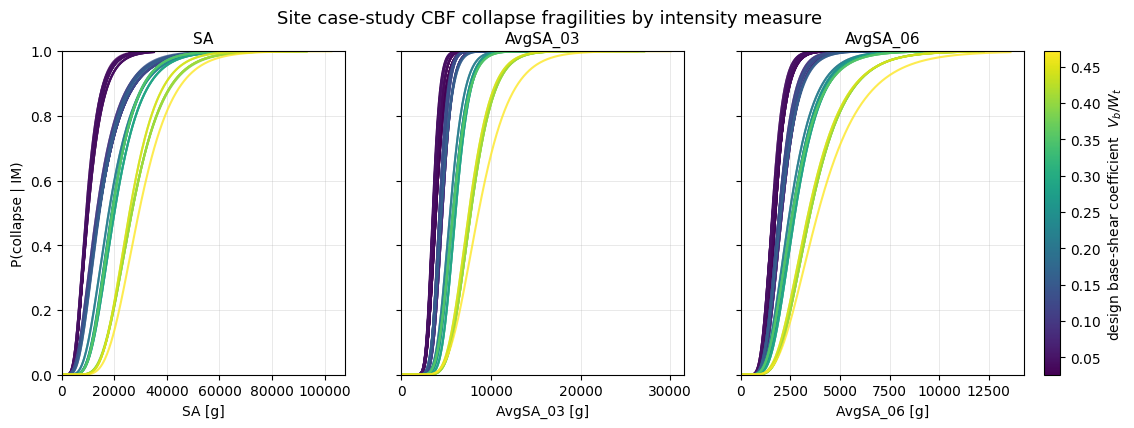

In [6]:
if not results:
    print("no converted fragilities to plot (run nb 011's IDA first)")
else:
    plot_tags = [t for t in TAGS if t in results]
    vbs = np.array([VB_COEFF[t] for t in plot_tags])
    norm = Normalize(vmin=vbs.min(), vmax=vbs.max())
    cmap = cm.viridis

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
    for ax, im in zip(axes, IM_ORDER):
        for tag in plot_tags:
            frag = results[tag][im]
            median_g = frag["median"]
            x = np.linspace(1e-3, median_g * 3.5, 400)
            y = lognorm.cdf(x, s=frag["dispersion"], scale=median_g)
            ax.plot(x, y, lw=1.5, alpha=0.8, color=cmap(norm(VB_COEFF[tag])))
        ax.set_title(im, fontsize=11)
        ax.set_xlabel(f"{im} [g]")
        ax.set_xlim(left=0)
        ax.set_ylim(0, 1)
        ax.grid(True, lw=0.5, alpha=0.4)
    axes[0].set_ylabel("P(collapse | IM)")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label(r"design base-shear coefficient  $V_b/W_t$")

    fig.suptitle("Site case-study CBF collapse fragilities by intensity measure", fontsize=13)
    fig_path = OUT_DIR / f"{IDA_TAG}_collapse_fragilities_by_im.png"
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    print(f"saved {fig_path}")
    plt.show()

### Fragility parameters

Median and dispersion of each structure's lognormal collapse fragility, in every
intensity measure. Rows are structures; columns are a two-level index (IM →
`median` / `dispersion`). Medians are reported in **g** (`median / g`);
dispersions are the dimensionless lognormal $\beta$.

In [ ]:
if not results:
    print("no converted fragilities to summarise (run nb 011's IDA first)")
    summary = pd.DataFrame()
else:
    rows = {}
    for tag in [t for t in TAGS if t in results]:
        row = {}
        for im in IM_ORDER:
            frag = results[tag][im]
            row[(im, "median")] = frag["median"] # g
            row[(im, "dispersion")] = frag["dispersion"]
        rows[tag] = row

    summary = pd.DataFrame.from_dict(rows, orient="index")
    summary.columns = pd.MultiIndex.from_tuples(summary.columns, names=["IM", "parameter"])
    summary = summary[IM_ORDER]  # enforce panel/IM column order
    summary.index.name = "structure"

    with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
        print(summary.to_string())

summary.to_csv(cfg["proc_data"]["wp1_sites_femap695_fc_summary"])

### Collapse median vs design base-shear coefficient

Collapse median (in g) against the design base-shear coefficient $V_b/W_t$, one
panel per intensity measure. Markers are coloured by $V_b/W_t$ (same *viridis*
scale as above) and joined in ascending order to show the capacity trend.

In [ ]:
def plot_param_vs_vbcoeff(param: str, ylabel: str, title: str):
    """3-panel scatter of a fragility parameter ('median'/'dispersion') vs Vb_coeff."""
    if not results:
        print("no converted fragilities to plot (run nb 011's IDA first)")
        return
    plot_tags = [t for t in TAGS if t in results]
    vbs = np.array([VB_COEFF[t] for t in plot_tags])
    order = np.argsort(vbs)
    vbs_s = vbs[order]
    norm = Normalize(vmin=vbs.min(), vmax=vbs.max())
    cmap = cm.viridis

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True)
    for ax, im in zip(axes, IM_ORDER):
        vals = np.array([summary.loc[t, (im, param)] for t in plot_tags])[order]
        ax.plot(vbs_s, vals, "-", color="0.75", lw=1, zorder=1)
        ax.scatter(vbs_s, vals, c=vbs_s, cmap=cmap, norm=norm,
                   s=45, edgecolor="k", linewidths=0.5, zorder=2)
        ax.set_title(im, fontsize=11)
        ax.set_xlabel(r"$V_b/W_t$")
        ax.grid(True, lw=0.5, alpha=0.4)
    axes[0].set_ylabel(ylabel)
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    return fig


fig_med = plot_param_vs_vbcoeff(
    "median", "collapse median [g]",
    "Site case-study CBF collapse median vs design base-shear coefficient")
if fig_med is not None:
    fig_med.savefig(OUT_DIR / "collapse_median_vs_vbcoeff.png", dpi=200, bbox_inches="tight")
    plt.show()

### Collapse dispersion vs design base-shear coefficient

The same layout for the lognormal dispersion $\beta$ — one panel per intensity
measure, plotted against $V_b/W_t$.

In [ ]:
fig_disp = plot_param_vs_vbcoeff(
    "dispersion", r"collapse dispersion  $\beta$",
    "Site case-study CBF collapse dispersion vs design base-shear coefficient")
if fig_disp is not None:
    fig_disp.savefig(OUT_DIR / "collapse_dispersion_vs_vbcoeff.png", dpi=200, bbox_inches="tight")
    plt.show()